In [9]:
from nca.model import *
from nca.rollout import *
from nca.viz import *
from nca.stats import *

import torch
import numpy as np

In [15]:
device = torch.device("cpu")
model = NCA()
state = torch.load("snapshots/froggy_model_noregen.pth", map_location=device)
model.load_state_dict(state)
model.eval()  # VERY IMPORTANT

NCA(
  (net): Sequential(
    (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
)

In [16]:
x0 = seed(1)  # initial seed, shape [1, C, H, W]
with torch.no_grad():
    states = rollout(model, x0, 100, None, None, True, True)
    # states_abl = rollout_with_ablation(model, x0, 400, 13)

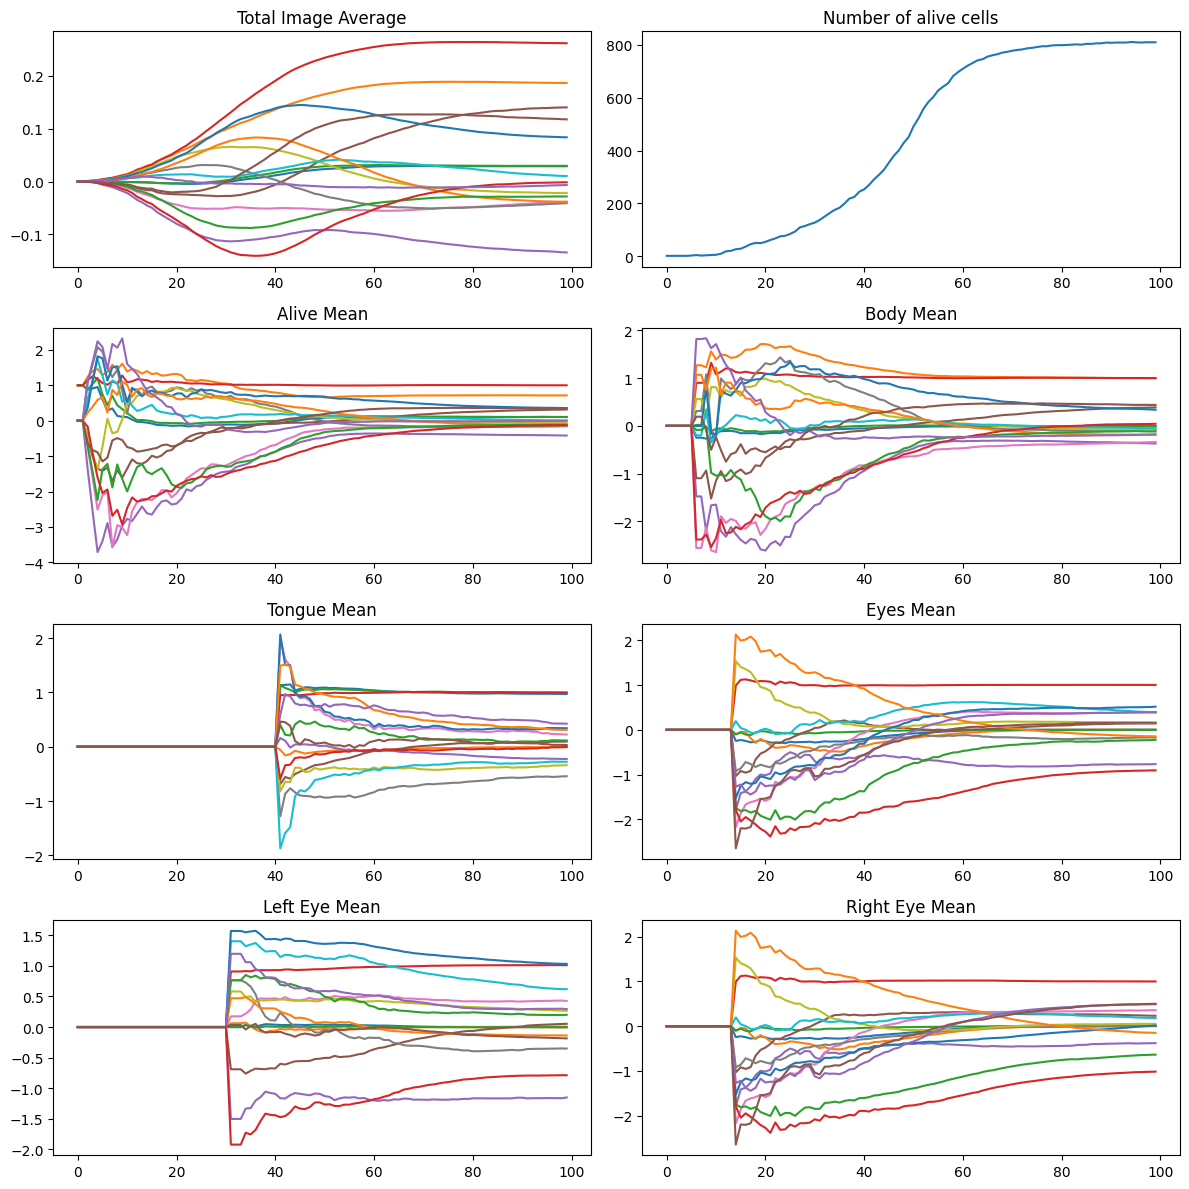

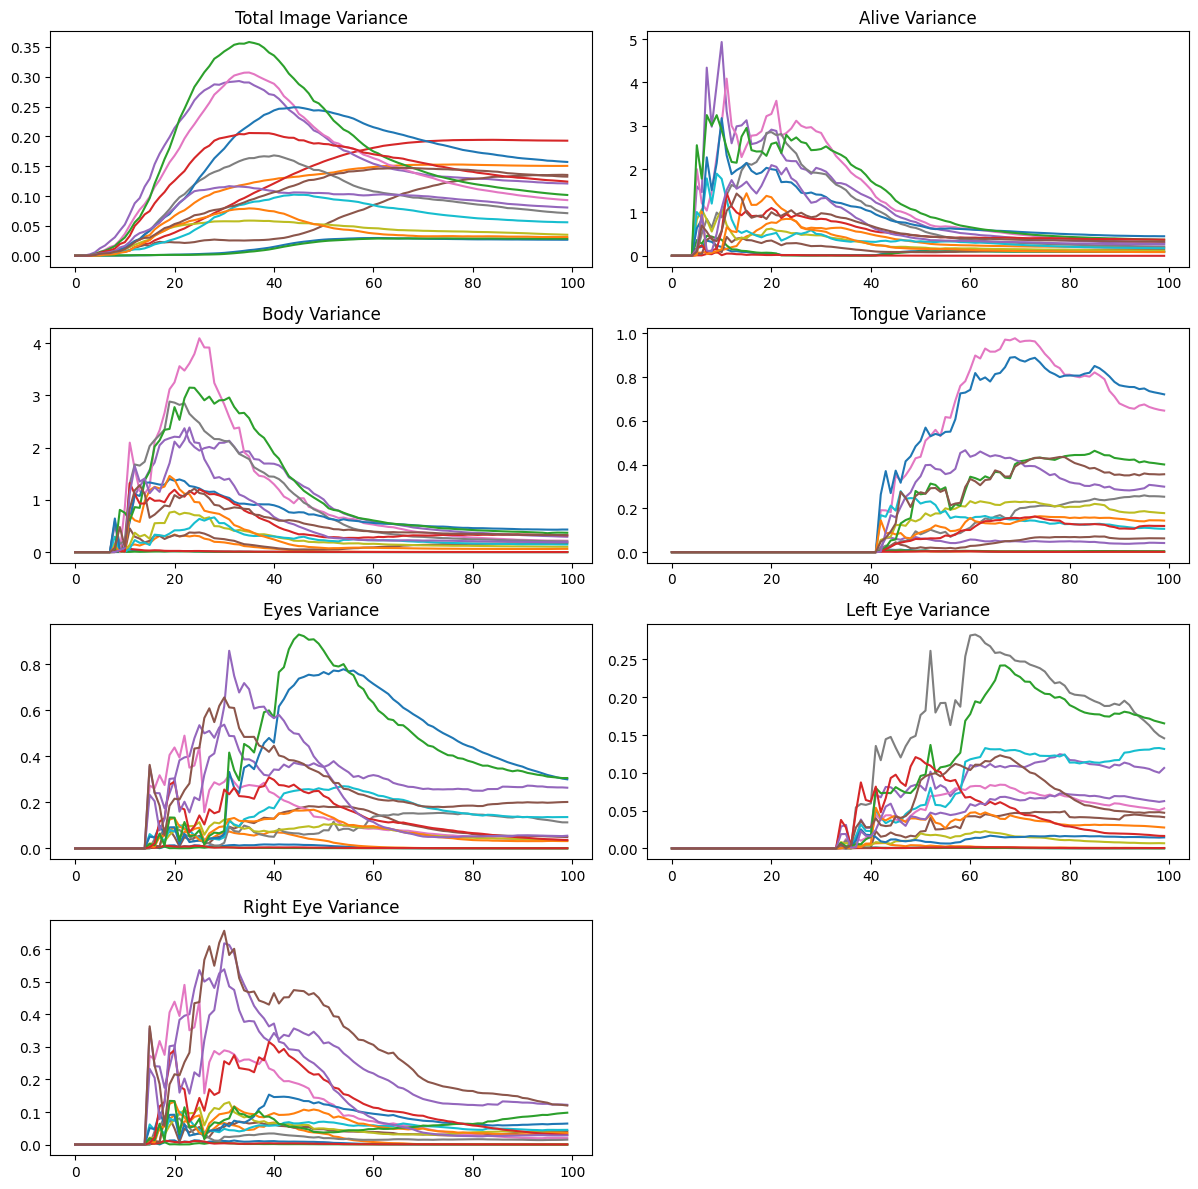

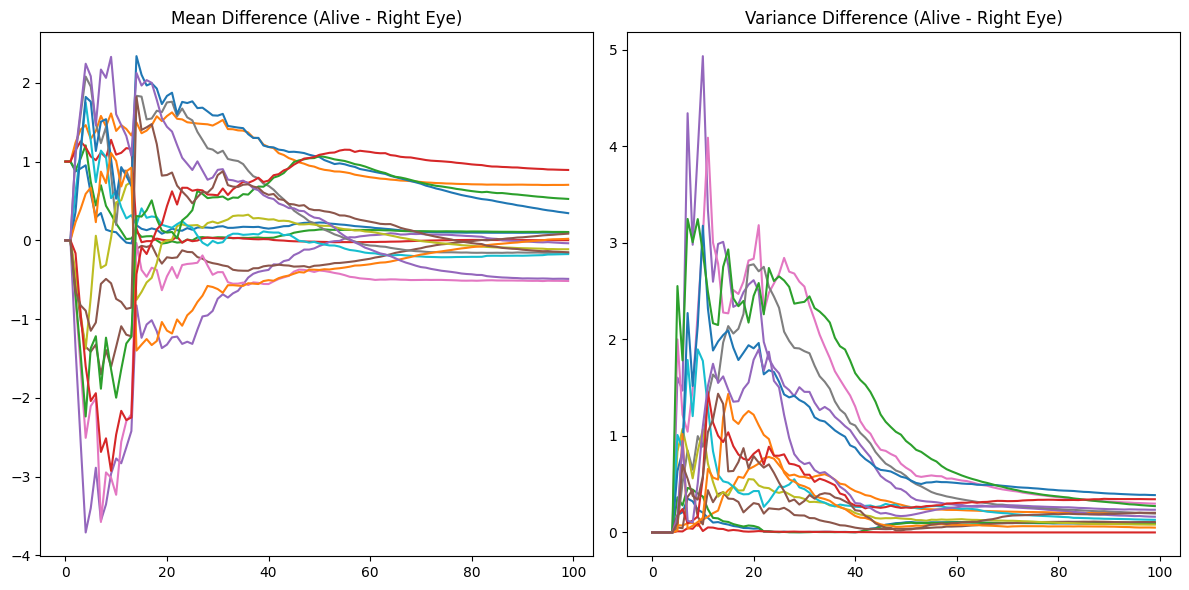

In [18]:
cell_states = get_states_by_part(states)
stats = compute_mean_var_by_part(cell_states)

plot_means_by_parts(cell_states, stats)
plot_variances_by_part(stats)
plot_alive_vs_r_eye_difference(stats)